<xarray.Dataset> Size: 34GB
Dimensions:          (tracer: 2, s_rho: 16, s_w: 17, eta_rho: 512, xi_rho: 833,
                      eta_u: 512, xi_u: 832, eta_v: 511, xi_v: 833,
                      eta_psi: 511, xi_psi: 832, ocean_time: 121)
Coordinates:
  * s_rho            (s_rho) float64 128B -0.9688 -0.9062 ... -0.09375 -0.03125
  * s_w              (s_w) float64 136B -1.0 -0.9375 -0.875 ... -0.0625 0.0
    lon_rho          (eta_rho, xi_rho) float64 3MB ...
    lat_rho          (eta_rho, xi_rho) float64 3MB ...
    lon_u            (eta_u, xi_u) float64 3MB ...
    lat_u            (eta_u, xi_u) float64 3MB ...
    lon_v            (eta_v, xi_v) float64 3MB ...
    lat_v            (eta_v, xi_v) float64 3MB ...
    lon_psi          (eta_psi, xi_psi) float64 3MB ...
    lat_psi          (eta_psi, xi_psi) float64 3MB ...
  * ocean_time       (ocean_time) datetime64[ns] 968B 2024-09-24 ... 2024-09-29
Dimensions without coordinates: tracer, eta_rho, xi_rho, eta_u, xi_u, eta_v,
        

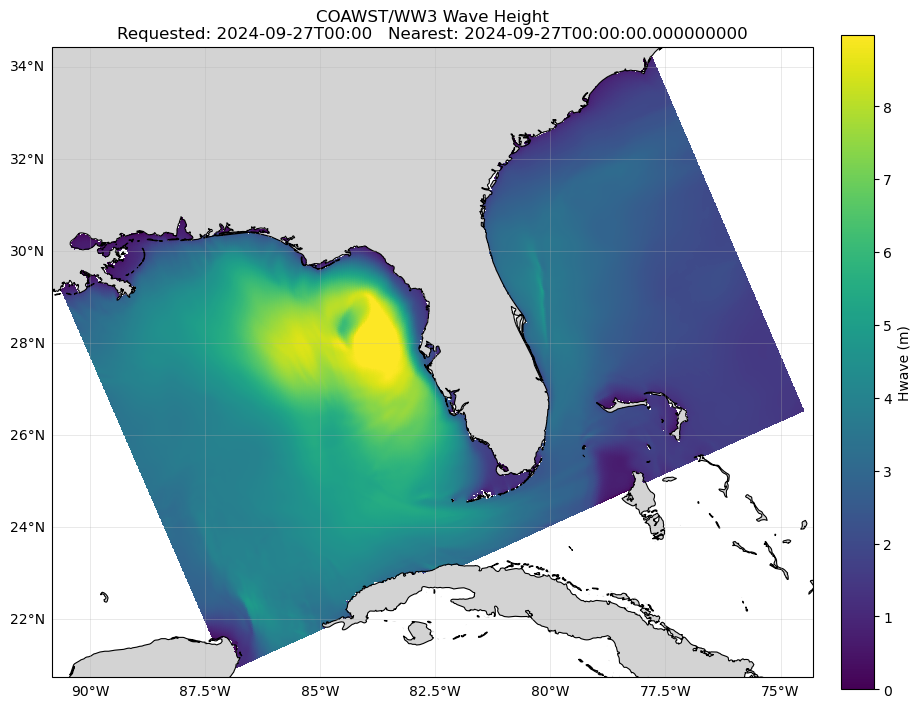

In [1]:
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt

# Optional, but recommended for map context
try:
    import cartopy.crs as ccrs
    import cartopy.feature as cfeature
    HAVE_CARTOPY = True
except ImportError:
    HAVE_CARTOPY = False

# ============================================================
# USER SETTINGS
# ============================================================
dap_url = (
    "https://geoport.whoi.edu/thredds/dodsC/"
    "vortexfs1/usgs/Projects/Helene2024/helene77/Output_89pct/"
    "coawst_gomsab_his.nc"
)

target_time = np.datetime64("2024-09-27T00:00")
wave_var = "Hwave"   # change if needed

vmin = 0.0
vmax = None
cmap = "viridis"

# ============================================================
# OPEN DATASET
# ============================================================
ds = xr.open_dataset(dap_url)

print(ds)
print("\nWave variable:")
print(ds[wave_var])

print("\nAvailable ocean_time range:")
print(ds["ocean_time"].values[0], "to", ds["ocean_time"].values[-1])

# ============================================================
# SELECT NEAREST TIME
# ============================================================
isel = ds.indexes["ocean_time"].get_indexer([target_time], method="nearest")[0]
tsel = ds["ocean_time"].values[isel]

print(f"\nRequested time: {target_time}")
print(f"Nearest model time used: {tsel}")

# ============================================================
# EXTRACT GRID AND DATA
# ============================================================
lon = ds["lon_rho"].values
lat = ds["lat_rho"].values
hwave = ds[wave_var].isel(ocean_time=isel).values

# Optional ROMS land/sea mask
if "mask_rho" in ds:
    mask_rho = ds["mask_rho"].values
    hwave_plot = np.where(mask_rho == 1, hwave, np.nan)
else:
    hwave_plot = hwave.copy()

hwave_plot = np.where(np.isfinite(hwave_plot), hwave_plot, np.nan)

if vmax is None:
    vmax = np.nanpercentile(hwave_plot, 99)

# ============================================================
# PLOT
# ============================================================
fig = plt.figure(figsize=(10, 8))

if HAVE_CARTOPY:
    ax = plt.axes(projection=ccrs.PlateCarree())

    pcm = ax.pcolormesh(
        lon,
        lat,
        hwave_plot,
        cmap=cmap,
        vmin=vmin,
        vmax=vmax,
        shading="auto",
        transform=ccrs.PlateCarree(),
    )

    ax.coastlines(resolution="10m", linewidth=0.8)
    ax.add_feature(cfeature.LAND, facecolor="lightgray", zorder=0)
    ax.add_feature(cfeature.BORDERS, linewidth=0.5)
    gl = ax.gridlines(draw_labels=True, linewidth=0.4, alpha=0.5)
    gl.top_labels = False
    gl.right_labels = False

    valid = np.isfinite(hwave_plot)
    if np.any(valid):
        lon_valid = lon[valid]
        lat_valid = lat[valid]
        pad_x = 0.2
        pad_y = 0.2
        ax.set_extent([
            np.nanmin(lon_valid) - pad_x,
            np.nanmax(lon_valid) + pad_x,
            np.nanmin(lat_valid) - pad_y,
            np.nanmax(lat_valid) + pad_y,
        ], crs=ccrs.PlateCarree())

else:
    ax = plt.axes()

    pcm = ax.pcolormesh(
        lon,
        lat,
        hwave_plot,
        cmap=cmap,
        vmin=vmin,
        vmax=vmax,
        shading="auto",
    )

    ax.set_xlabel("Longitude (degrees)")
    ax.set_ylabel("Latitude (degrees)")
    ax.set_aspect("equal", adjustable="box")
    ax.grid(True, alpha=0.3)

cbar = plt.colorbar(pcm, ax=ax, shrink=0.85, pad=0.03)
cbar.set_label("Hwave (m)")

ax.set_title(f"COAWST/WW3 Wave Height\nRequested: {target_time}   Nearest: {str(tsel)}")

plt.tight_layout()
plt.show()